<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> Mid-Term Assignment - CSV to Data Warehouse </b></h3>

Introduction
fazer um indice
explicar pq escoli este dataset(maybe so no video)
explicar a junção


In [96]:
import pandas as pd
import ast # so that we can explode some info
import numpy as np
pd.options.display.float_format = '{:.2f}'.format

In [39]:
df_1 = pd.read_csv('tmdb_5000_movies.csv')
df_2 = pd.read_csv('tmdb_5000_credits.csv')

In [40]:
# the 'id' and 'movie_id' are the same but with different names, so we combine based on that id
df_combined = pd.merge(df_1, df_2, left_on = 'id', right_on = 'movie_id')

In [41]:
# the problem of this merge is that the df_combined will have both the 'id' and the 'movie_id', we need to remove one
df_combined.drop(columns= ['movie_id', 'title_y'], inplace = True)
df_combined.rename(columns= {'title_x' : 'title'}, inplace= True)

**Tratar dos Missing Values**

In [42]:
df_combined.isna().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                       0
crew                       0
dtype: int64

In [43]:
df_combined = df_combined.dropna(subset=['release_date'])
df_combined = df_combined.dropna(subset=['runtime'])


In [44]:
df_combined.drop(columns = ['homepage', 'tagline', 'overview', 'keywords', 'status',], inplace = True)


In [45]:
df_combined.dtypes

budget                    int64
genres                   object
id                        int64
original_language        object
original_title           object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
title                    object
vote_average            float64
vote_count                int64
cast                     object
crew                     object
dtype: object

In [46]:
df_combined['release_date'] = pd.to_datetime(df_combined['release_date'])
df_combined['budget'] = pd.to_numeric(df_combined['budget'], errors='coerce')
df_combined['revenue'] = pd.to_numeric(df_combined['revenue'], errors='coerce')

## **TRATAR DA COLUNA DOS GENRES**

### **Dimension 1 - Dates**

This is the dimension with the dates. All of the information about the release_date of the movies is here.

In [47]:
dim1_date = pd.DataFrame({
    'movie_id': df_combined['id'],
    'release_date': df_combined['release_date'],
    'year': pd.to_datetime(df_combined['release_date']).dt.year,
    'month': pd.to_datetime(df_combined['release_date']).dt.month,
    'quarter': pd.to_datetime(df_combined['release_date']).dt.quarter})

In [48]:
dim1_date #just to check

,movie_id,release_date,year,month,quarter
0,19995,2009-12-10,2009,12,4
1,285,2007-05-19,2007,5,2
2,206647,2015-10-26,2015,10,4
3,49026,2012-07-16,2012,7,3
4,49529,2012-03-07,2012,3,1
...,...,...,...,...,...
4798,9367,1992-09-04,1992,9,3
4799,72766,2011-12-26,2011,12,4
4800,231617,2013-10-13,2013,10,4
4801,126186,2012-05-03,2012,5,2


### **Dimension 2 - Genres**

In this dimension, we will find all the information about the genre of the movie. Keep in mind, that there are some movies with more than one genre

In [49]:
df_combined['genres'] = df_combined['genres'].apply(ast.literal_eval)
df_genres_exploded = df_combined[['id', 'genres']].explode('genres')
df_genres_exploded = df_genres_exploded.dropna(subset=['genres'])
df_genres_exploded

,id,genres
0,19995,"{'id': 28, 'name': 'Action'}"
0,19995,"{'id': 12, 'name': 'Adventure'}"
0,19995,"{'id': 14, 'name': 'Fantasy'}"
0,19995,"{'id': 878, 'name': 'Science Fiction'}"
1,285,"{'id': 12, 'name': 'Adventure'}"
...,...,...
4800,231617,"{'id': 35, 'name': 'Comedy'}"
4800,231617,"{'id': 18, 'name': 'Drama'}"
4800,231617,"{'id': 10749, 'name': 'Romance'}"
4800,231617,"{'id': 10770, 'name': 'TV Movie'}"


In [50]:
dim_genres = pd.DataFrame({
    'movie_id': df_genres_exploded['id'],
    'genre_id': df_genres_exploded['genres'].apply(lambda x: x['id']),
    'genre_name': df_genres_exploded['genres'].apply(lambda x: x['name'])})
dim_genres

,movie_id,genre_id,genre_name
0,19995,28,Action
0,19995,12,Adventure
0,19995,14,Fantasy
0,19995,878,Science Fiction
1,285,12,Adventure
...,...,...,...
4800,231617,35,Comedy
4800,231617,18,Drama
4800,231617,10749,Romance
4800,231617,10770,TV Movie


### **Dimension 3 -** Language

**isto é pa dizer no video**

"To ensure the project remained scalable and maintainable, I implemented a dynamic mapping for the primary languages. For less frequent language codes, I used a fallback function to retain the original ISO codes, preventing data loss while keeping the ETL pipeline lean."

Here we can see there are 37 different languages

In [51]:
# This shows you every language code you actually have
print(df_combined['original_language'].unique())

['en' 'ja' 'fr' 'zh' 'es' 'de' 'hi' 'ru' 'ko' 'te' 'cn' 'it' 'nl' 'ta'
 'sv' 'th' 'da' 'xx' 'hu' 'cs' 'pt' 'is' 'tr' 'nb' 'af' 'pl' 'he' 'ar'
 'vi' 'ky' 'id' 'ro' 'fa' 'no' 'sl' 'ps' 'el']


As there are 37 different languages on this dataset, we chose to only map the languages corresponding to the most percentage. As we can see here, the english and the french movies represents more than 95%. That is the reason why we decide to not map each language

In [52]:
lang_distribution = df_combined['original_language'].value_counts(normalize=True) * 100

#Show the top 10
print("Language Distribution (%)")
print(lang_distribution.head(12))

Language Distribution (%)
original_language
en    93.812500
fr     1.458333
es     0.666667
zh     0.562500
de     0.562500
hi     0.395833
ja     0.333333
it     0.270833
cn     0.250000
ko     0.229167
ru     0.229167
pt     0.187500
Name: proportion, dtype: float64


In [53]:
lang_map = {
    'en': 'English', 'ja': 'Japanese', 'fr': 'French', 'zh': 'Chinese',
    'es': 'Spanish', 'de': 'German', 'hi': 'Hindi', 'ru': 'Russian',
    'ko': 'Korean', 'cn': 'Cantonese', 'it': 'Italian', 'pt': 'Portuguese'
}

In [54]:
dim3_language = pd.DataFrame({
    'movie_id': df_combined['id'],
    'language_code': df_combined['original_language'],
    'language_name': df_combined['original_language'].map(lang_map).fillna('Other')
})
dim3_language

,movie_id,language_code,language_name
0,19995,en,English
1,285,en,English
2,206647,en,English
3,49026,en,English
4,49529,en,English
...,...,...,...
4798,9367,es,Spanish
4799,72766,en,English
4800,231617,en,English
4801,126186,en,English


### **Dimension 4 - Cast**

In [55]:
df_combined['cast'] = df_combined['cast'].apply(ast.literal_eval)
df_cast_exploded = df_combined[['id', 'cast']].explode('cast')
df_cast_exploded = df_cast_exploded.dropna(subset=['cast'])
df_cast_exploded

,id,cast
0,19995,"{'cast_id': 242, 'character': 'Jake Sully', 'c..."
0,19995,"{'cast_id': 3, 'character': 'Neytiri', 'credit..."
0,19995,"{'cast_id': 25, 'character': 'Dr. Grace August..."
0,19995,"{'cast_id': 4, 'character': 'Col. Quaritch', '..."
0,19995,"{'cast_id': 5, 'character': 'Trudy Chacon', 'c..."
...,...,...
4802,25975,"{'cast_id': 8, 'character': 'Himself', 'credit..."
4802,25975,"{'cast_id': 9, 'character': 'Himself', 'credit..."
4802,25975,"{'cast_id': 10, 'character': 'Himself', 'credi..."
4802,25975,"{'cast_id': 11, 'character': 'Himself', 'credi..."


In [56]:
gender_map = {0: 'Unknown', 1: 'Female', 2: 'Male', 3: 'Non-Binary'}

In [57]:
dim4_cast = pd.DataFrame({
    'movie_id': df_cast_exploded['id'],
    'actor_id': df_cast_exploded['cast'].apply(lambda x: x['id']),
    'actor_name': df_cast_exploded['cast'].apply(lambda x: x['name']),
    'character': df_cast_exploded['cast'].apply(lambda x: x['character']),
    'gender_label': df_cast_exploded['cast'].apply(lambda x: x.get('gender')).map(gender_map)
})

In [58]:
dim4_cast

,movie_id,actor_id,actor_name,character,gender_label
0,19995,65731,Sam Worthington,Jake Sully,Male
0,19995,8691,Zoe Saldana,Neytiri,Female
0,19995,10205,Sigourney Weaver,Dr. Grace Augustine,Female
0,19995,32747,Stephen Lang,Col. Quaritch,Male
0,19995,17647,Michelle Rodriguez,Trudy Chacon,Female
...,...,...,...,...,...
4802,25975,21315,Eric Roberts,Himself,Male
4802,25975,2171,Griffin Dunne,Himself,Unknown
4802,25975,2231,Samuel L. Jackson,Himself,Male
4802,25975,14407,Matt LeBlanc,Himself,Male


### **Dimension 5 - Crew**

In [59]:
df_combined['crew'] = df_combined['crew'].apply(ast.literal_eval)
df_crew_exploded = df_combined[['id','crew']].explode('crew')
df_crew_exploded = df_crew_exploded.dropna(subset = ['crew'])
df_crew_exploded

,id,crew
0,19995,"{'credit_id': '52fe48009251416c750aca23', 'dep..."
0,19995,"{'credit_id': '539c47ecc3a36810e3001f87', 'dep..."
0,19995,"{'credit_id': '54491c89c3a3680fb4001cf7', 'dep..."
0,19995,"{'credit_id': '54491cb70e0a267480001bd0', 'dep..."
0,19995,"{'credit_id': '539c4a4cc3a36810c9002101', 'dep..."
...,...,...
4802,25975,"{'credit_id': '58ce021b9251415a390165d9', 'dep..."
4802,25975,"{'credit_id': '58ce0232c3a36850e90157da', 'dep..."
4802,25975,"{'credit_id': '52fe44e8c3a368484e03da8d', 'dep..."
4802,25975,"{'credit_id': '52fe44e8c3a368484e03da87', 'dep..."


** We choose to only keep the directors because that is the more valuable information. we ususally dont need to know whos the colourist but we need to know the director** 


**data warehousing is about choosing what we really need, this way we reduced the number of rows from 197.000 to just 5000**

In [60]:
df_directors = df_crew_exploded[df_crew_exploded['crew'].apply(lambda x: x['job'] == 'Director')]

In [61]:
dim5_crew = pd.DataFrame({
    'movie_id': df_directors['id'],
    'director_id': df_directors['crew'].apply(lambda x: x['id']),
    'director_name': df_directors['crew'].apply(lambda x: x['name']),
    'job': 'Director', # Optional: good for showing what the role is
    'gender_label' : df_directors['crew'].apply(lambda x: x.get('gender')).map(gender_map)
})


dim5_crew

,movie_id,director_id,director_name,job,gender_label
0,19995,2710,James Cameron,Director,Male
1,285,1704,Gore Verbinski,Director,Male
2,206647,39,Sam Mendes,Director,Male
3,49026,525,Christopher Nolan,Director,Male
4,49529,7,Andrew Stanton,Director,Male
...,...,...,...,...,...
4800,231617,1219158,Scott Smith,Director,Unknown
4801,126186,208138,Daniel Hsia,Director,Male
4802,25975,85563,Brian Herzlinger,Director,Male
4802,25975,94471,Jon Gunn,Director,Male


## **Fact Table**

In [81]:
fact_table = df_combined[['id','budget','revenue', 'runtime', 'popularity', 'vote_average','vote_count']]
fact_table['revenue'] = fact_table['revenue'].replace(0, np.nan)
fact_table['budget'] = fact_table['budget'].replace(0, np.nan)

fact_table['profit'] = fact_table['revenue'] - fact_table['budget']
fact_table['ROI'] = fact_table['profit'] / fact_table['budget']

# Standardize the ID name
fact_table.rename(columns={'id': 'movie_id'}, inplace=True)

C:\Users\laura\AppData\Local\Temp\ipykernel_33820\4051402287.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_table['revenue'] = fact_table['revenue'].replace(0, np.nan)
C:\Users\laura\AppData\Local\Temp\ipykernel_33820\4051402287.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_table['budget'] = fact_table['budget'].replace(0, np.nan)
C:\Users\laura\AppData\Local\Temp\ipykernel_33820\4051402287.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

In [82]:
fact_table

,movie_id,budget,revenue,runtime,popularity,vote_average,vote_count,profit,ROI
0,19995,237000000.0,2.787965e+09,162.0,150.437577,7.2,11800,2.550965e+09,10.763566
1,285,300000000.0,9.610000e+08,169.0,139.082615,6.9,4500,6.610000e+08,2.203333
2,206647,245000000.0,8.806746e+08,148.0,107.376788,6.3,4466,6.356746e+08,2.594590
3,49026,250000000.0,1.084939e+09,165.0,112.312950,7.6,9106,8.349391e+08,3.339756
4,49529,260000000.0,2.841391e+08,132.0,43.926995,6.1,2124,2.413910e+07,0.092843
...,...,...,...,...,...,...,...,...,...
4798,9367,220000.0,2.040920e+06,81.0,14.269792,6.6,238,1.820920e+06,8.276909
4799,72766,9000.0,NaN,85.0,0.642552,5.9,5,NaN,NaN
4800,231617,NaN,NaN,120.0,1.444476,7.0,6,NaN,NaN
4801,126186,NaN,NaN,98.0,0.857008,5.7,7,NaN,NaN


In [83]:

# Quick Sanity Check
print(f"Fact Table rows: {len(fact_table)}")
print(f"Dimensions linked: {fact_table['movie_id'].isin(dim1_date['movie_id']).all()}")

Fact Table rows: 4800
Dimensions linked: True


In [84]:
# Check Genres (since one movie has many genres, we check if the ID exists at least once)
genres_ok = fact_table['movie_id'].isin(dim_genres['movie_id']).all()
print(f"Genres Link: {genres_ok}")

# Check Crew (Directors)
crew_ok = fact_table['movie_id'].isin(dim5_crew['movie_id']).all()
print(f"Crew Link: {crew_ok}")

Genres Link: False
Crew Link: False


"During data validation, I found that the Crew and Genre dimensions did not have 100% coverage. This is expected in real-world datasets where some films lack metadata. To handle this, I used Inner Joins in my SQL queries to focus only on movies with complete information, ensuring my analysis of 'Profit by Director' remained accurate."

In [85]:
orphans = fact_table[~fact_table['movie_id'].isin(dim5_crew['movie_id'])]
print(f"Number of movies without a Director: {len(orphans)}")
print(orphans[['movie_id']].head())

Number of movies without a Director: 29
      movie_id
3661     19615
3670    447027
3729     26379
3977     55831
4068    371085


In [86]:
import sqlite3

# 1. Connect (this creates the file 'movies.db' in your folder)
conn = sqlite3.connect('movies_warehouse.db')

# 2. Save all tables
fact_table.to_sql('fact_table', conn, index=False, if_exists='replace')
dim1_date.to_sql('dim_date', conn, index=False, if_exists='replace')
dim_genres.to_sql('dim_genres', conn, index=False, if_exists='replace')
dim3_language.to_sql('dim_language', conn, index=False, if_exists='replace')
dim4_cast.to_sql('dim_cast', conn, index=False, if_exists='replace')
dim5_crew.to_sql('dim_crew', conn, index=False, if_exists='replace')


print("Success! Your Star Schema is now a real SQL Database.")

Success! Your Star Schema is now a real SQL Database.


In [87]:
query_directors = """
SELECT 
    d.director_name, 
    COUNT(f.movie_id) AS total_movies,
    ROUND(SUM(f.profit), 2) AS total_profit
FROM fact_table f
JOIN dim_crew d ON f.movie_id = d.movie_id
WHERE f.profit IS NOT NULL
GROUP BY d.director_name
ORDER BY total_profit DESC
LIMIT 5;
"""

df_top_directors = pd.read_sql_query(query_directors, conn)
df_top_directors

,director_name,total_movies,total_profit
0,Steven Spielberg,27,7.479893e+09
1,Peter Jackson,9,5.205643e+09
2,James Cameron,7,5.136669e+09
3,Michael Bay,12,4.422525e+09
4,Christopher Nolan,8,3.222483e+09


In [88]:
conn.close()

In [99]:
# 1. Establish the connection
conn = sqlite3.connect('movies_warehouse.db')

# 2. Query 1: Top 5 Most Profitable Directors
query_1 = """
SELECT 
    d.director_name, 
    COUNT(f.movie_id) AS movie_count,
    ROUND(SUM(f.profit), 2) AS total_profit
FROM fact_table f
JOIN dim_crew d ON f.movie_id = d.movie_id
WHERE f.profit IS NOT NULL
GROUP BY d.director_name
HAVING movie_count > 2
ORDER BY total_profit DESC
LIMIT 5;
"""

# 3. Query 2: ROI by Gender
query_2 = """
SELECT 
    d.gender_label, 
    ROUND(AVG(f.roi), 2) AS average_roi,
    COUNT(f.movie_id) AS total_films
FROM fact_table f
JOIN dim_crew d ON f.movie_id = d.movie_id
WHERE d.gender_label != 'Unknown'
GROUP BY d.gender_label;
"""


query_3 = '''
SELECT 
    g.genre_name, 
    COUNT(f.movie_id) AS total_movies,
    ROUND(AVG(f.revenue), 2) AS avg_revenue,
    ROUND(SUM(f.revenue), 2) AS total_revenue
FROM fact_table f
JOIN dim_genres g ON f.movie_id = g.movie_id
WHERE f.revenue IS NOT NULL
GROUP BY g.genre_name
ORDER BY total_revenue DESC;
'''

query_4 = '''
SELECT 
    d.quarter, 
    COUNT(f.movie_id) AS movie_count,
    ROUND(AVG(f.budget), 2) AS avg_budget,
    ROUND(AVG(f.profit), 2) AS avg_profit
FROM fact_table f
JOIN dim_date d ON f.movie_id = d.movie_id
WHERE f.profit IS NOT NULL
GROUP BY d.quarter
ORDER BY d.quarter;
'''


query_5 = '''
SELECT 
    c.actor_name, 
    COUNT(f.movie_id) AS film_count,
    ROUND(AVG(f.roi), 2) AS avg_roi
FROM fact_table f
JOIN dim_cast c ON f.movie_id = c.movie_id
WHERE f.roi IS NOT NULL
GROUP BY c.actor_name
HAVING film_count >= 5  -- Only look at actors with at least 5 movies
ORDER BY avg_roi DESC
LIMIT 10;
'''

# Display results
print("--- TOP DIRECTORS BY PROFIT ---")
display(pd.read_sql_query(query_1, conn))

print("\n--- ROI BY GENDER ---")
display(pd.read_sql_query(query_2, conn))

print('--- REVENUE BY GENRE ---')
display(pd.read_sql_query(query_3, conn))

print('--- PROFIT BY QUARTER ---')
display(pd.read_sql_query(query_4, conn))

print('--- ACTOR BY ROI ---')
display(pd.read_sql_query(query_5, conn))

# 4. Close at the very end of the notebook
# conn.close()

--- TOP DIRECTORS BY PROFIT ---


,director_name,movie_count,total_profit
0,Steven Spielberg,27,7479893164.00
1,Peter Jackson,9,5205642820.00
2,James Cameron,7,5136669439.00
3,Michael Bay,12,4422524638.00
4,Christopher Nolan,8,3222483234.00



--- ROI BY GENDER ---


,gender_label,average_roi,total_films
0,Female,2.53,269
1,Male,3358.54,3876


--- REVENUE BY GENRE ---


,genre_name,total_movies,avg_revenue,total_revenue
0,Adventure,675,244209720.82,164841561551.00
1,Action,940,173361611.19,162959914515.00
2,Comedy,1174,104566028.63,122760517608.00
3,Drama,1527,78396191.21,119710983984.00
4,Thriller,959,107664678.07,103250426269.00
5,Family,382,218018949.45,83283238689.00
6,Fantasy,351,233567521.15,81982199925.00
7,Science Fiction,439,185795525.62,81564235745.00
8,Romance,604,88811486.00,53642137545.00
9,Animation,191,276503496.68,52812167865.00


--- PROFIT BY QUARTER ---


,quarter,movie_count,avg_budget,avg_profit
0,1,656,34005109.34,50605379.02
1,2,757,52174215.54,123362197.57
2,3,932,34313148.16,58187691.44
3,4,884,42409632.58,89826997.96


--- ACTOR BY ROI ---


,actor_name,film_count,avg_roi
0,Chuck Hamilton,5,1700021.73
1,Harry Wilson,5,1700003.76
2,Katrina Bowden,6,166668.35
3,Niecy Nash,6,166668.30
4,Paz de la Huerta,6,166667.16
5,Boris Kodjoe,7,142859.65
6,Kathleen Turner,9,111112.13
7,Martin Donovan,11,90909.59
8,Katie Featherston,5,2606.31
9,John Larroquette,6,62.29


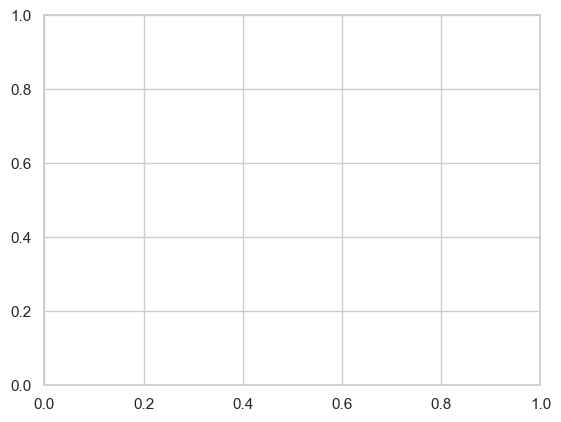

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a professional theme
sns.set_theme(style="whitegrid")
# Prevent scientific notation in charts
plt.ticklabel_format(style='plain', axis='y')

C:\Users\laura\AppData\Local\Temp\ipykernel_33820\4031976375.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=df_genres, x='total_revenue', y='genre_name', palette='viridis')


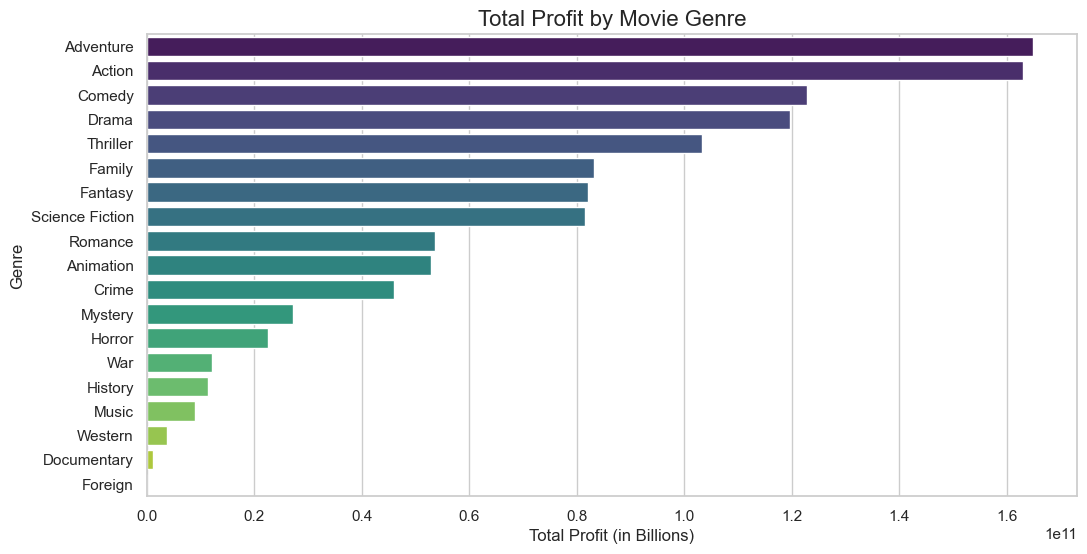

In [106]:
df_genres = pd.read_sql_query(query_3, conn)

# 2. Create the plot
plt.figure(figsize=(12, 6))
plot = sns.barplot(data=df_genres, x='total_revenue', y='genre_name', palette='viridis')

plt.title('Total Profit by Movie Genre', fontsize=16)
plt.xlabel('Total Profit (in Billions)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()